In [4]:
print("Hello PlaceMux!")


Hello PlaceMux!


In [5]:
import pandas as pd
import numpy as np
import random

from sklearn.datasets import load_iris

In [6]:
random.seed(42)
np.random.seed(42)

print("Random seed set successfully!")

Random seed set successfully!


In [7]:
iris = load_iris()

In [8]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
print(df.shape)

(150, 5)


In [11]:
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [13]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [14]:
print(df["target"].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [18]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [19]:
print("Training Set:", X_train.shape)
print("Validation Set:", X_valid.shape)
print("Test Set:", X_test.shape)

Training Set: (105, 4)
Validation Set: (22, 4)
Test Set: (23, 4)


In [20]:
model = DummyClassifier(strategy="most_frequent")

In [21]:
model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [22]:
predictions = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.30434782608695654


In [24]:
import os

os.makedirs("../logs", exist_ok=True)

metrics = pd.DataFrame({
    "Model": ["DummyClassifier"],
    "Accuracy": [accuracy]
})

metrics.to_csv("../logs/metrics.csv", index=False)

print("Metrics saved successfully!")

Metrics saved successfully!


In [25]:
# ======================================
# Task 2 - Pre-Project Feature Scope & Profiling
# ======================================

# Problem Statement

Predict the species of an iris flower using its physical measurements.

## Success Metric

Classification Accuracy

In [29]:
target = "target"

print("Target Variable:", target)

Target Variable: target


## Target Definition

The target variable is **target**, which represents the species of an iris flower.

There are three classes:

- 0 → Setosa
- 1 → Versicolor
- 2 → Virginica

In [30]:
print(df["target"].head(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64


In [31]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


## Sample Label Interpretation

| Sample | Target | Species |
|--------|--------|----------|
| 1 | 0 | Setosa |
| 2 | 0 | Setosa |
| 3 | 0 | Setosa |
| 4 | 0 | Setosa |
| 5 | 0 | Setosa |

In [32]:
features = df.columns[:-1]

print("Candidate Features:")
for feature in features:
    print("-", feature)

Candidate Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [33]:
print("Number of Features:", len(features))

Number of Features: 4


In [34]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [36]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [37]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


## Feature Quality Report

| Feature | Data Type | Missing Values | Quality |
|----------|-----------|----------------|---------|
| Sepal Length | Float | 0 | Good |
| Sepal Width | Float | 0 | Good |
| Petal Length | Float | 0 | Good |
| Petal Width | Float | 0 | Good |

### Observation

- All features are numeric.
- No missing values were found.
- The features are suitable for building a classification model.

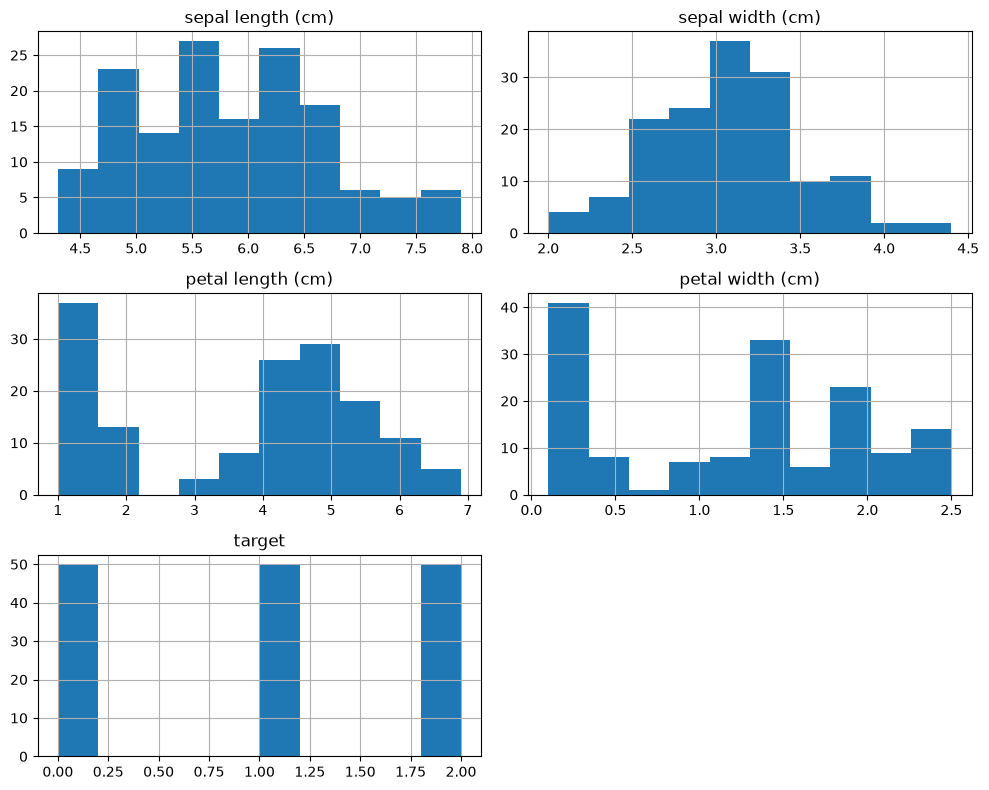

In [38]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8))

plt.tight_layout()

plt.show()

In [39]:
print("Dataset Columns:")
print(df.columns)

Dataset Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [40]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature Columns:")
print(X.columns.tolist())

print("\nTarget Column:")
print(y.name)

Feature Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Column:
target


In [41]:
if "target" in X.columns:
    print("Warning: Data leakage detected!")
else:
    print("No data leakage detected.")

No data leakage detected.


In [42]:
correlation = df.corr()

print(correlation)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  


## Leakage Check Report

### Objective
Verify that none of the input features reveal the target value.

### Observation
- The target column is separated before model training.
- Only flower measurements are used as input features.
- No feature contains the answer or future information.

### Result
No data leakage was detected. All features are safe to use for model training.

In [43]:
print("Final Features Used:")
for column in X.columns:
    print("-", column)

Final Features Used:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [44]:
class_counts = df["target"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [45]:
class_percentage = df["target"].value_counts(normalize=True) * 100

print("Class Percentage:")
print(class_percentage)

Class Percentage:
target
0    33.333333
1    33.333333
2    33.333333
Name: proportion, dtype: float64


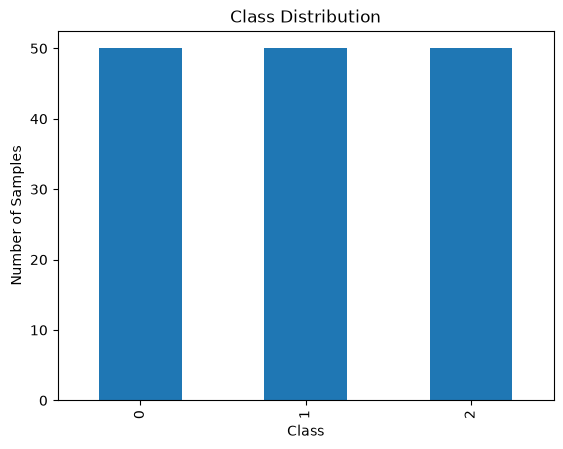

In [46]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [47]:
print("Total Samples:", len(df))

Total Samples: 150


## Class Balance Report

### Observation

- Total samples: **150**
- Number of classes: **3**
- Each class contains **50 samples**
- Each class represents approximately **33.3%** of the dataset.

### Conclusion

The dataset is balanced, so classification accuracy is an appropriate evaluation metric and no additional balancing techniques are required.

In [48]:
go_decision = "GO"

print("Project Decision:", go_decision)

Project Decision: GO


In [49]:
model_type = "Classification"

print("Selected Modelling Approach:", model_type)

Selected Modelling Approach: Classification


# Modelling Approach

### Selected Approach
Classification

### Reason

The target variable represents three discrete flower species (Setosa, Versicolor, and Virginica). Since the objective is to predict one of these predefined classes, classification is the appropriate machine learning approach.

# Go / No-Go Decision

### Data Quality

- No missing values
- No significant data quality issues
- Balanced class distribution
- No data leakage detected

### Decision

**GO**

The dataset is suitable for building and evaluating a machine learning classification model.

# Task 2 Summary

Successfully completed:

- Defined the problem statement
- Selected the target variable
- Identified candidate features
- Profiled feature quality
- Verified there is no data leakage
- Checked class balance
- Selected a classification approach
- Approved the dataset for model development